# 3. Comparing groups on one tree

Tutorial 02 drew one tree for one dataset. This one draws the same tree once
per group — early against late, one tissue region against another — with every
cell type pinned to the same position in all of them. Because nothing moves
between the figures, differences in what the groups contain are visible by
flicking between the pictures rather than by holding numbers in your head.

That is the whole idea: **one shared scaffold, one figure per group.** The
scaffold is built from every cell type found anywhere in the data, so a type
that is missing from one group leaves a visible gap there instead of quietly
closing up.

## Why this tutorial changes tissue

Tutorials 01 and 02 used blood. Blood cells are finished products — a monocyte
is not on its way to becoming anything else — so a comparison across blood
samples can show differences in *proportion* but has no development in it.

Here we use a **developing human retina**, sampled at ten timepoints from week
9 to week 24 after fertilisation. A retina is built in a known order over those
weeks, which gives the comparison something real to find.

## Getting the data

The atlas comes from CZ CELLxGENE Discover: about 226,000 cell nuclei from 14
donors, published with the paper below. We download the file the site serves
and take a slice of it locally.

> Zuo Z, Cheng X, Ferdous S, *et al.* "Single cell dual-omic atlas of the human
> developing retina." *Nat Commun* **15**, 6792 (2024).
> doi:[10.1038/s41467-024-50853-5](https://doi.org/10.1038/s41467-024-50853-5)

**This download is 3.1 GB and will take a while.** It happens once; the cell
below skips it if the file is already there. If you would rather not keep a
file that size, delete it after running the tutorial — everything after Step 1
works on the much smaller slice.

In [1]:
import pathlib
import shutil
import urllib.request

URL = ("https://datasets.cellxgene.cziscience.com/"
       "883270e9-41e6-4c2c-b352-b15c292d2a34.h5ad")
SOURCE = pathlib.Path("retina_fetal.h5ad")

if not SOURCE.exists():
    with urllib.request.urlopen(URL) as response, open(SOURCE, "wb") as handle:
        shutil.copyfileobj(response, handle)

## Step 1. Take a slice without loading the whole file

Reading all 3.1 GB into memory needs well over 10 GB of RAM. It is not
necessary: `backed="r"` opens the file leaving the expression matrix on disk,
so only the rows you ask for are ever read.

25,000 nuclei is plenty here. Every cell type we care about still has enough
cells to be drawn, and the whole tutorial then runs in a few minutes.

In [2]:
import anndata as ad
import numpy as np

full = ad.read_h5ad(SOURCE, backed="r")

rng = np.random.default_rng(0)
chosen = np.sort(rng.choice(full.n_obs, 25_000, replace=False))
adata = full[chosen].to_memory()
full.file.close()

adata.shape

(25000, 35469)

**Take a plain random slice, not a balanced one.** It is tempting to sample the
same number of cells from every group so the figures are "fair". Don't — the
number printed beside each cell type is a count of cells, and forcing the
groups to be equal sizes makes those counts mean something other than what they
say. A random slice keeps the real proportions.

## Step 2. Get back to raw counts

**HECTOR needs raw counts.** Files from CELLxGENE store normalised values in
`.X` and keep the original counts in `.raw` — so the matrix you get by default
is the wrong one. This catches people out, and the symptom is poor predictions
rather than an error.

One line fixes it. The check afterwards is worth keeping in your own code:
raw counts are whole numbers.

In [3]:
adata = adata.raw.to_adata()

print("largest value:", adata.X.max(), "— whole numbers:",
      float(adata.X.max()) == int(adata.X.max()))

largest value: 3395.0 — whole numbers: True


## Step 3. Annotate the cells

The same three lines as the earlier tutorials. This dataset is **single
nucleus** rather than whole cell, which HECTOR handles: on this data its calls
agree with the labels the original authors published for about 94% of nuclei.

In [4]:
import hector

predictor = hector.HECTOR("human")
predictions = predictor.predict(adata, label_format="name")
predictor.write_predictions(adata, predictions)

adata.obs["hector_prediction"].value_counts().head(8)

<environment>/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ☑️  MLX encoder loaded
  ☑️  MLX CellTypeEmbedder loaded
  ☑️  MLX HPLHead loaded
  📂 Loaded Memory Bank: 100,000 anchor cells
 🎉 Model loaded successfully! 🥳
   Prediction hardware: GPU (Apple M1 Max, MLX)
   Supported cell types: 1407
  [INFO] Making predictions on 25000 cells...
  Settings: top_k=1, use_grit=True, zero_shot=True
  Step 0: Checking gene IDs...
  Step 1: Gene Matching and Reordering ...
  Gene matching: 4983/5000 (99.7% of reference genes found)
  Step 2: Processing expression data...
  MLX adaptive batch size: 22274 (budget 16.2 GB, floor 5.7 GB)


  Encoding: 100%|██████████████████████████████| 2/2 [00:40<00:00, 20.45s/batch]


  Step 3: Predicting cell types...


  Predicting: 100%|████████████████████████████| 4/4 [00:03<00:00,  1.07batch/s]


  [INFO] Applying GRIT refinement...

  GRIT REFINEMENT
  Metric          Min      5%       25%      Median   75%      95%      Max     
  ---------------------------------------------------------------------------
  Entropy         2.55     2.65     2.69     2.85     3.02     3.25     3.78    
  ---------------------------------------------------------------------------

  [Auto-Thresholding]: Detected Threshold: 3.0642. Refining the lower 20.5% of the prediction distribution

  Step 4: Refining 5,127 cells using all 25,000 cells as neighbors ...


  kNN graph: 100%|██████████████████████████████| 8/8 [00:01<00:00,  7.07tile/s]


  ✅ Predictions complete!
  Step 5: Formatting results...
  ✅ Results formatted as DataFrame with shape (25000, 3)
  Rare-cell rollup summary: threshold=20 cells (min(1.0% of 25000, 20)), 36 type(s) bucketed as 'Rare Cells', 96 cell(s) affected
  Annotated adata.obs with 5 columns (prefix='hector_', 25000/25000 cells matched)


hector_prediction
retinal progenitor cell           8306
retinal rod cell                  3912
retinal ganglion cell             2206
midget ganglion cell of retina    2165
GABAergic amacrine cell           1312
retinal cone cell                 1124
retina horizontal cell            1022
amacrine cell                     1005
Name: count, dtype: int64

## Step 4. Define the groups to compare

A comparison needs a column in `adata.obs` holding one label per cell. Anything
categorical works — treatment, donor, timepoint, tissue.

The ten timepoints are too many to look at side by side, so we bin them into
three: **Early** is weeks 9–14, **Mid** is weeks 15–17, **Late** is weeks
20–24. The ages are recorded as text like `"15th week post-fertilization
stage"`, so we pull the number out first.

Keep group names short and free of spaces and punctuation — they become part
of the output filenames.

In [5]:
adata.obs["week"] = (adata.obs["development_stage"]
                     .astype(str).str.extract(r"(\d+)")[0].astype(int))

stage_of = {**{w: "Early" for w in (9, 11, 12, 13, 14)},
            **{w: "Mid" for w in (15, 17)},
            **{w: "Late" for w in (20, 21, 24)}}
adata.obs["stage"] = adata.obs["week"].map(stage_of)

adata.obs["stage"].value_counts()

stage
Late     10413
Early    10153
Mid       4434
Name: count, dtype: int64

## Step 5. Compare across developmental time

One call produces one figure per group. `groups=` fixes the order — without it
the groups are sorted alphabetically, which would put "Late" before "Mid".

Comparison plots use a shared static scaffold and are written as PDF files.
If `.html` is requested, HECTOR warns and replaces it with `.pdf`.

In [6]:
hector.create_trajectory_comparison(
    predictor,
    adata,
    groupby="stage",
    groups=["Early", "Mid", "Late"],
    output_prefix="03_stage.pdf",
    label_format="name",
    layout_mode="radial",
)


HECTOR Trajectory Comparison
Groups (stage): ['Early', 'Mid', 'Late']

[Full dataset] Running predictions...
[INFO] Reusing cached predictions from adata.uns['hector_prediction_core_manifest'] (same cells, same settings). Pass force_recompute=True to recompute.
[INFO] Extracting visualization vectors (Unity Mode: GRIT=On)...
[INFO] Processing 25000 cells...
[INFO] Reusing cached predictions from adata.uns['hector_prediction_core_manifest'] (same cells, same settings). Pass force_recompute=True to recompute.

[Union] Building shared ontology subgraph...
  Union cell types: 38
[Union] Building shared scaffold...
  Union tree: 39 nodes, 38 edges

[Early] Rendering → 03_stage_Early.pdf
  Visible: 23/39 nodes, 22/38 edges, 10042 cells
[HECTOR] auto-detected stable_source_zone=0.2000, stable_target_zone=0.2000  (mode=fallback)
✅ Saved radial tree: 03_stage_Early.pdf

[Mid] Rendering → 03_stage_Mid.pdf
  Visible: 28/39 nodes, 27/38 edges, 4314 cells
[HECTOR] auto-detected stable_source_zone=

The log line worth reading is `Visible: N/M nodes` for each group. It reports
how much of the shared scaffold that group actually occupies:

| group | nodes occupied |
| --- | --- |
| Early, weeks 9–14 | 23 of 39 |
| Mid, weeks 15–17 | 28 of 39 |
| Late, weeks 20–24 | 39 of 39 |

The tree fills in as the retina builds itself.

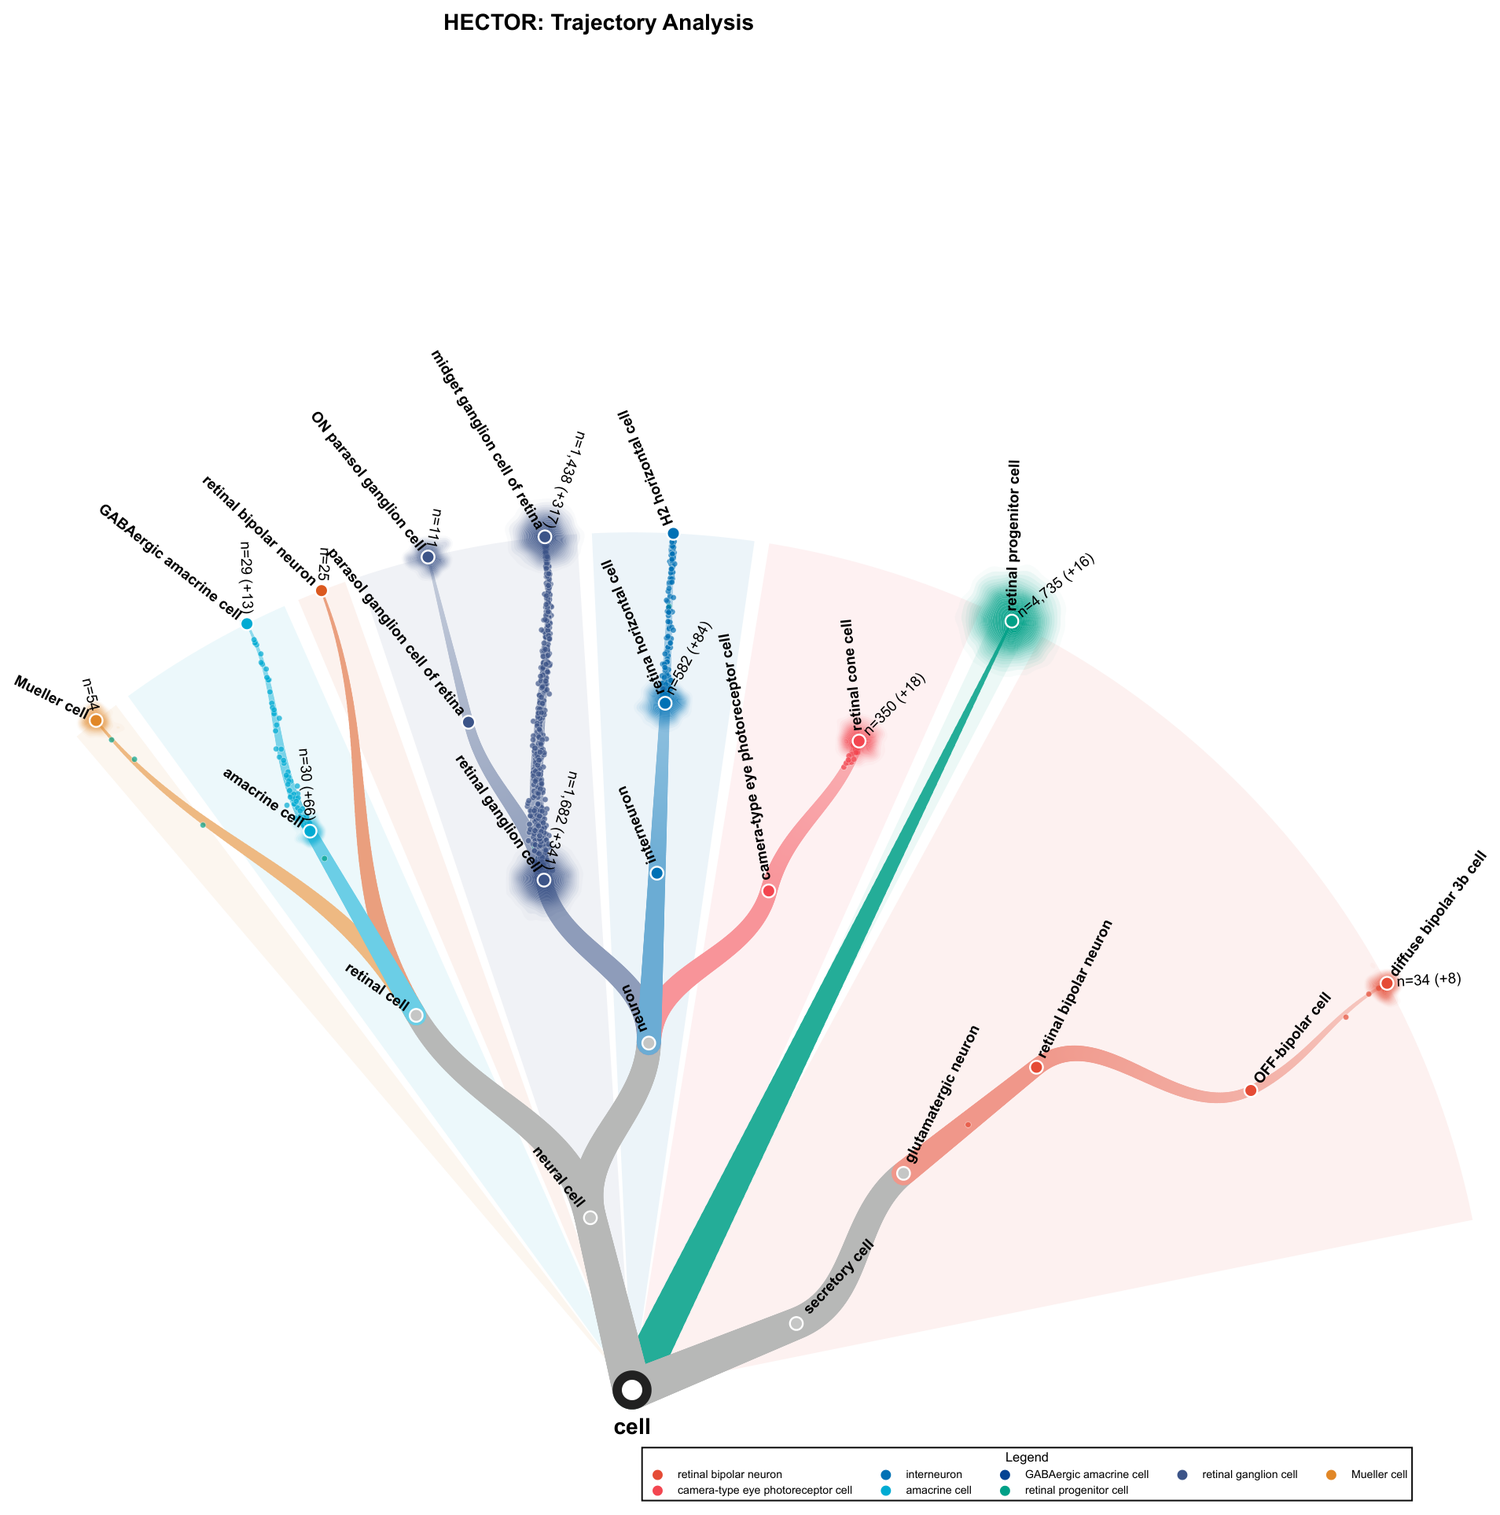

**Early, weeks 9–14.** One node dominates: `retinal progenitor cell`, the
unspecialised pool everything else is made from, with 4,751 of the group's
10,042 cells. The ganglion branch is already well populated — 2,023 at
`retinal ganglion cell` and 1,755 at `midget ganglion cell of retina`. The
bipolar branch is just the parent node and one subtype, and no rods are drawn.

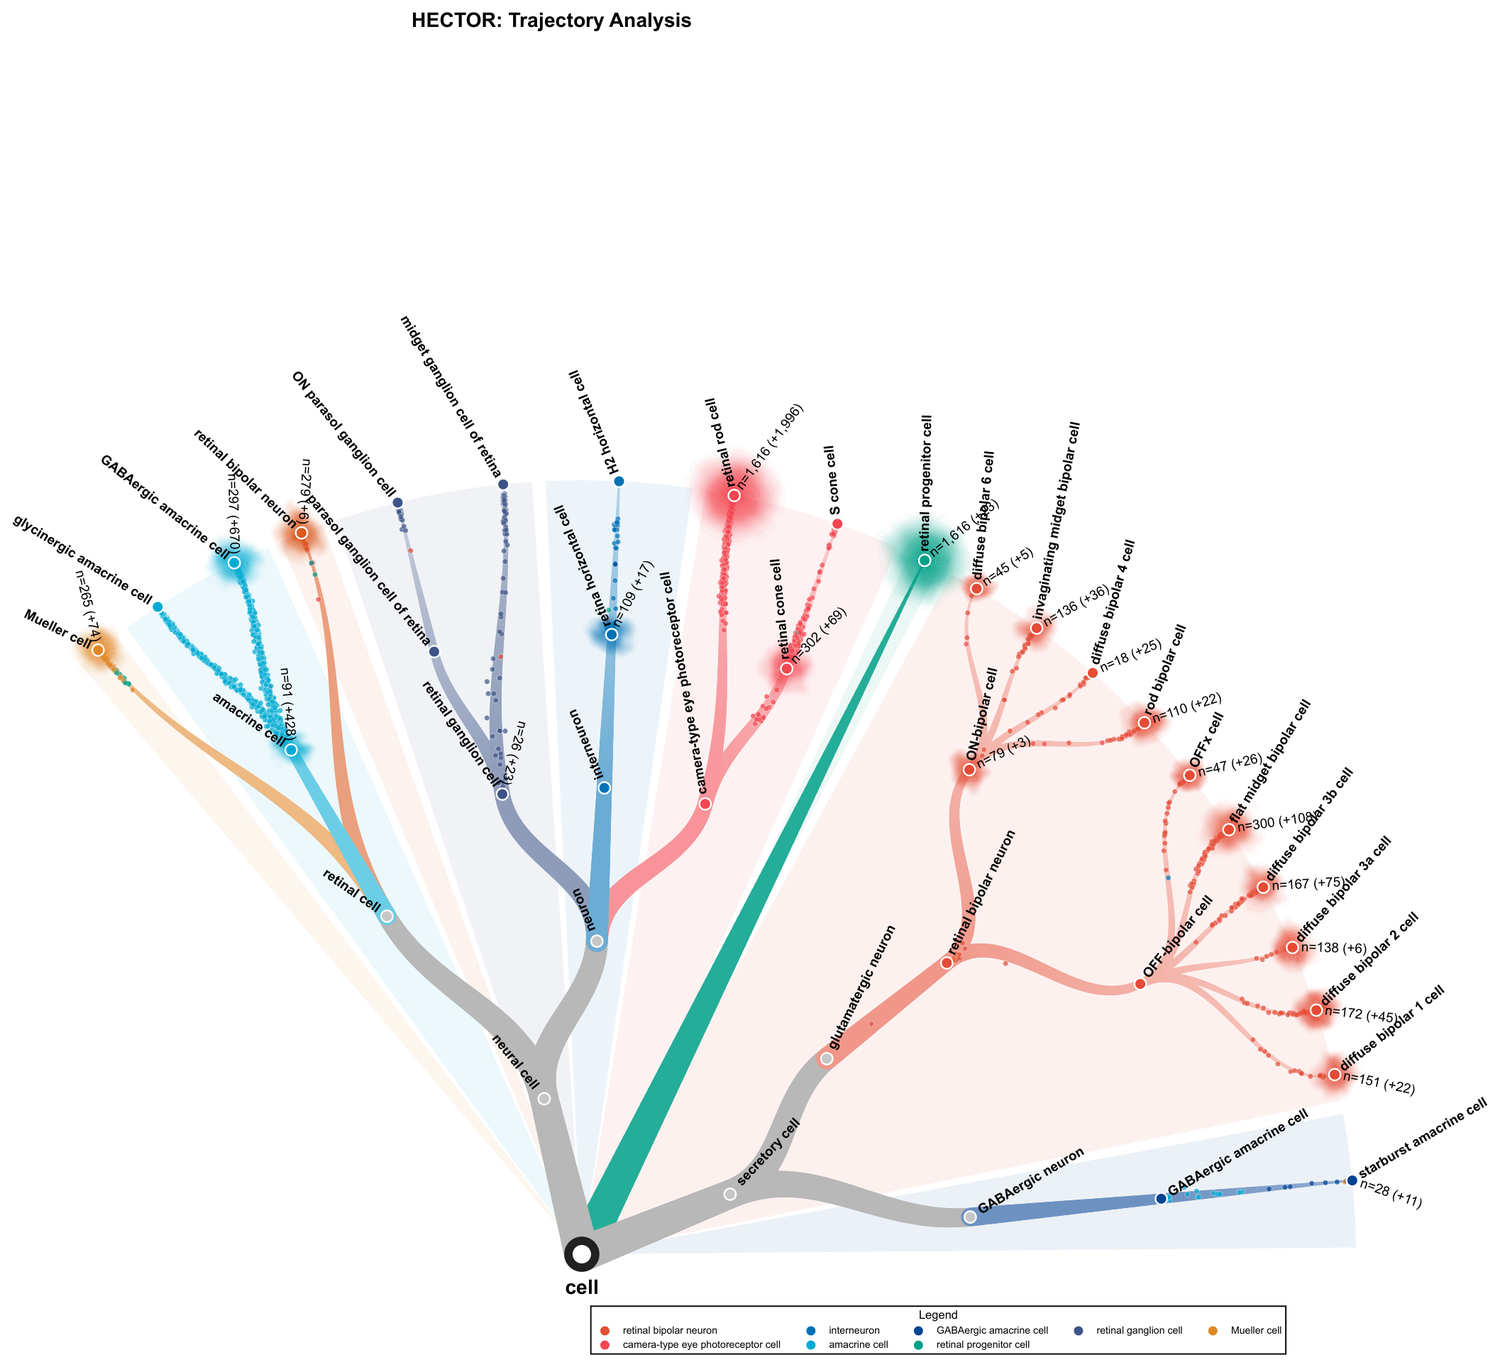

**Late, weeks 20–24.** The same tree, inverted. Progenitors are down to 1,639,
and the `retinal ganglion cell` node from 2,023 to 49. Rods are now the largest
population on the page at 3,612, up from 12. The bipolar branch has opened into
ten subtypes: flat midget, invaginating midget, rod bipolar, OFFx, and diffuse
bipolar 1, 2, 3a, 3b, 4 and 6.

## Step 6. Which types appear when

The figures show it; this puts a number on it. For each cell type, find the
earliest group in which it clears the 20-cell threshold used for drawing.

In [7]:
import pandas as pd

ORDER = ["Early", "Mid", "Late"]
counts = pd.crosstab(adata.obs["hector_prediction"], adata.obs["stage"])
counts = counts.reindex(columns=ORDER).fillna(0).astype(int)
counts = counts[counts.sum(axis=1) >= 20]

first_seen = counts.apply(
    lambda row: next((g for g in ORDER if row[g] >= 20), "not drawn"), axis=1)

for group in ORDER:
    types = sorted(first_seen[first_seen == group].index)
    print(f"\nfirst drawn in {group} ({len(types)}):")
    for name in types:
        print("   ", name)


first drawn in Early (12):
    GABAergic amacrine cell
    H2 horizontal cell
    Mueller cell
    ON parasol ganglion cell
    amacrine cell
    diffuse bipolar 3b cell
    midget ganglion cell of retina
    retina horizontal cell
    retinal bipolar neuron
    retinal cone cell
    retinal ganglion cell
    retinal progenitor cell

first drawn in Mid (3):
    flat midget bipolar cell
    retinal rod cell
    starburst amacrine cell

first drawn in Late (11):
    OFFx cell
    ON-bipolar cell
    S cone cell
    diffuse bipolar 1 cell
    diffuse bipolar 2 cell
    diffuse bipolar 3a cell
    diffuse bipolar 4 cell
    diffuse bipolar 6 cell
    glycinergic amacrine cell
    invaginating midget bipolar cell
    rod bipolar cell


The order that comes out is the published order in which a retina is built.
Ganglion cells, horizontal cells and cones are all present in the earliest
group. Rods arrive in the middle one. Eight of the ten bipolar subtypes appear
only in the last, along with the S cone and glycinergic amacrine cells.

**This is what makes the comparison a developmental result.** HECTOR only ever
says what each cell *is*. Sorting those answers by age supplies the *when*, and
the two together describe the process. Nothing in the model knows about
development; the time axis is doing that work.

Read it as a sequence of arrivals, not as a clean partition. Two things blunt
the edges. A type is listed the moment it clears 20 cells, so a rare type
arrives late in this table merely by becoming common — `diffuse bipolar 3b` is
listed Early on a count of 34, while its siblings wait for Late. And the
`Mueller cell` node is drawn from the Early group even though Müller glia are
the last class a retina finishes, because immature ones are already numerous
enough to pass the threshold.

## Step 7. Comparing two samples instead of two timepoints

The commoner situation is not a time course but two samples — treated against
control, patient against healthy. The call is identical; only the column
changes.

This atlas supports that directly. Each retina was sampled in two places: the
**macula** at the centre, and the **periphery** at the edge. A retina matures
from the centre outwards, so at any given age the two regions are at different
stages of the same process — and because both come from the same donor on the
same day, no difference between them can be a batch effect.

The week-9 samples are whole retina, taken before the two regions can be told
apart, so they are excluded here.

In [8]:
adata.obs["region"] = adata.obs["tissue"].astype(str).map(
    {"macula lutea": "Macula", "peripheral region of retina": "Periphery"})

paired = adata[adata.obs["region"].notna()].copy()

hector.create_trajectory_comparison(
    predictor,
    paired,
    groupby="region",
    groups=["Macula", "Periphery"],
    output_prefix="03_region.pdf",
    label_format="name",
    layout_mode="radial",
)


HECTOR Trajectory Comparison
Groups (region): ['Macula', 'Periphery']

[Full dataset] Running predictions...
  Step 0: Checking gene IDs...
  Step 1: Gene Matching and Reordering ...
  Gene matching: 4983/5000 (99.7% of reference genes found)
  Step 2: Processing expression data...
  MLX adaptive batch size: 24263 (budget 18.4 GB, floor 5.7 GB)


  Encoding: 100%|██████████████████████████████| 1/1 [00:35<00:00, 35.17s/batch]


[INFO] Reusing public prediction annotation from adata.obs/adata.uns...
[INFO] Extracting visualization vectors (Unity Mode: GRIT=On)...
[INFO] Processing 24263 cells...
[INFO] Reusing cached predictions from adata.uns['hector_prediction_core_manifest'] (same cells, same settings). Pass force_recompute=True to recompute.

[Union] Building shared ontology subgraph...
  Union cell types: 41
[Union] Building shared scaffold...
  Union tree: 40 nodes, 39 edges

[Macula] Rendering → 03_region_Macula.pdf
  Visible: 40/40 nodes, 39/39 edges, 13039 cells
[HECTOR] auto-detected stable_source_zone=0.2000, stable_target_zone=0.2000  (mode=fallback)
✅ Saved radial tree: 03_region_Macula.pdf

[Periphery] Rendering → 03_region_Periphery.pdf
  Visible: 32/40 nodes, 31/39 edges, 11057 cells
[HECTOR] auto-detected stable_source_zone=0.2000, stable_target_zone=0.2000  (mode=fallback)
✅ Saved radial tree: 03_region_Periphery.pdf

[Done] 2 comparison plots written.


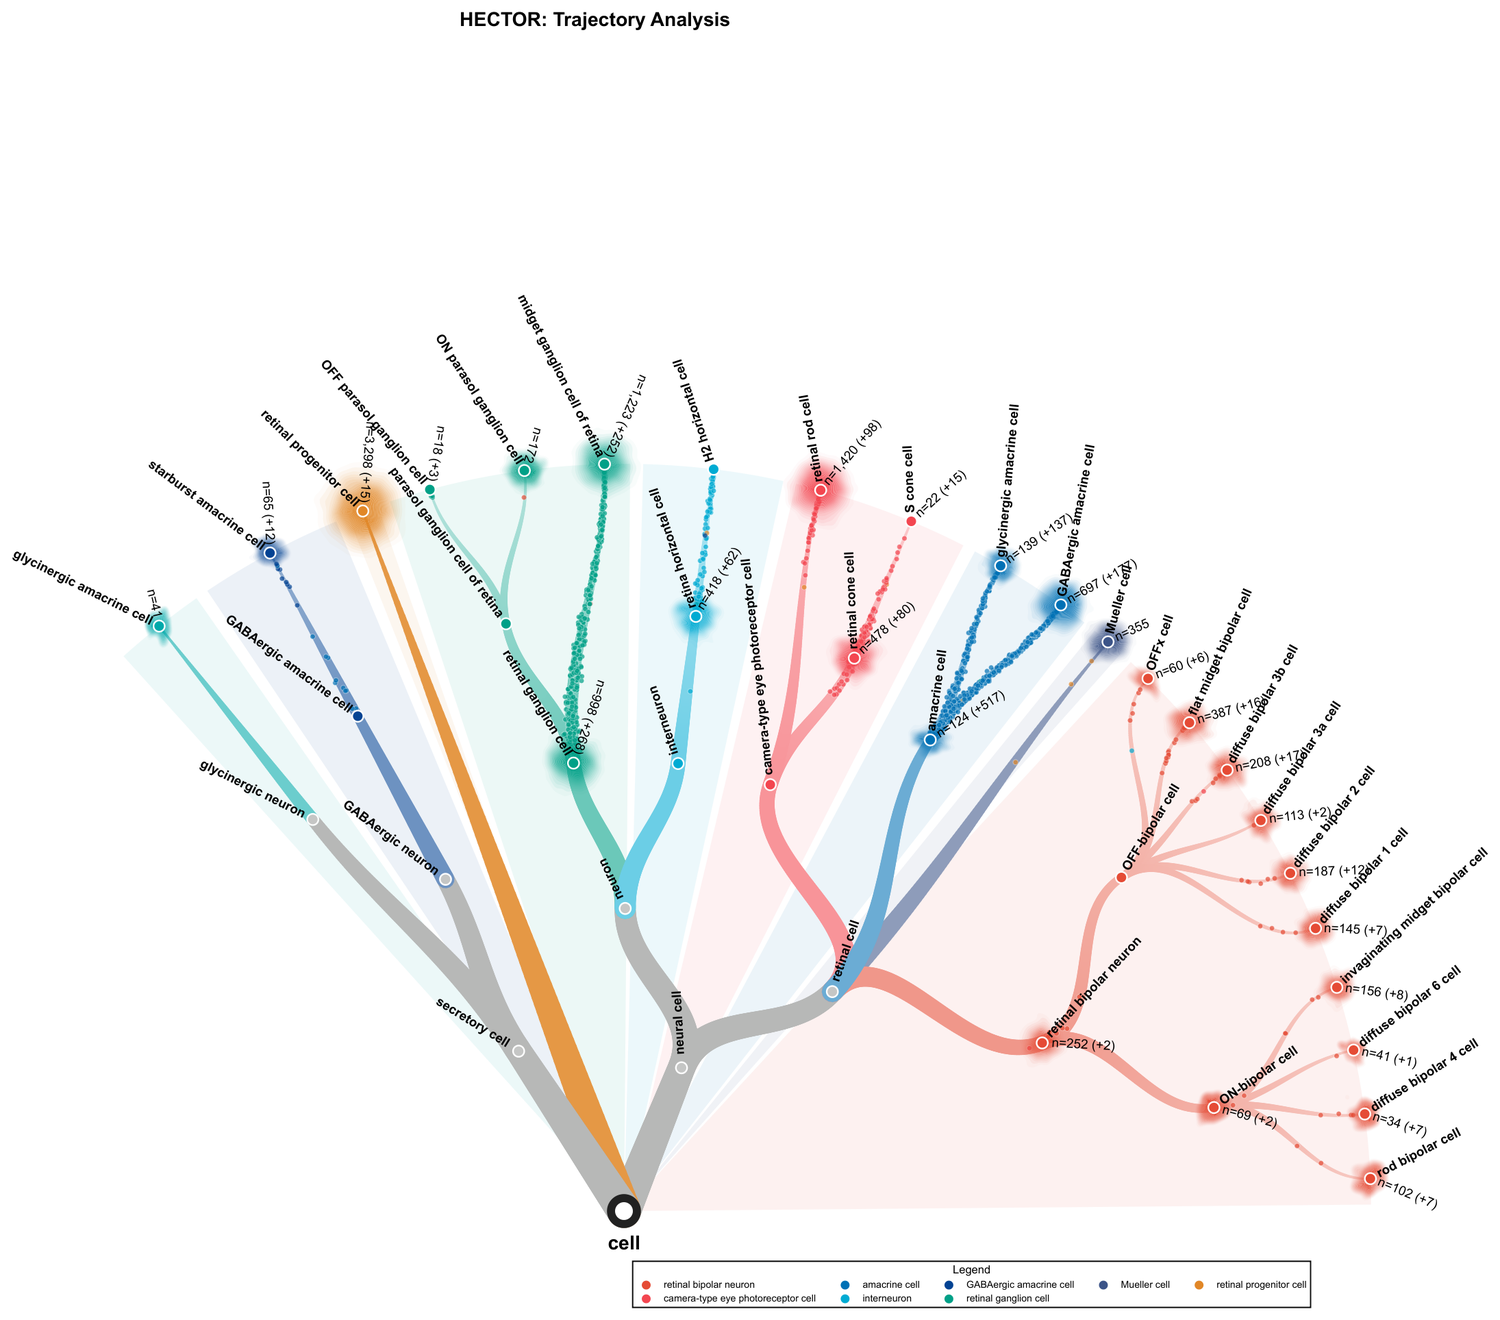

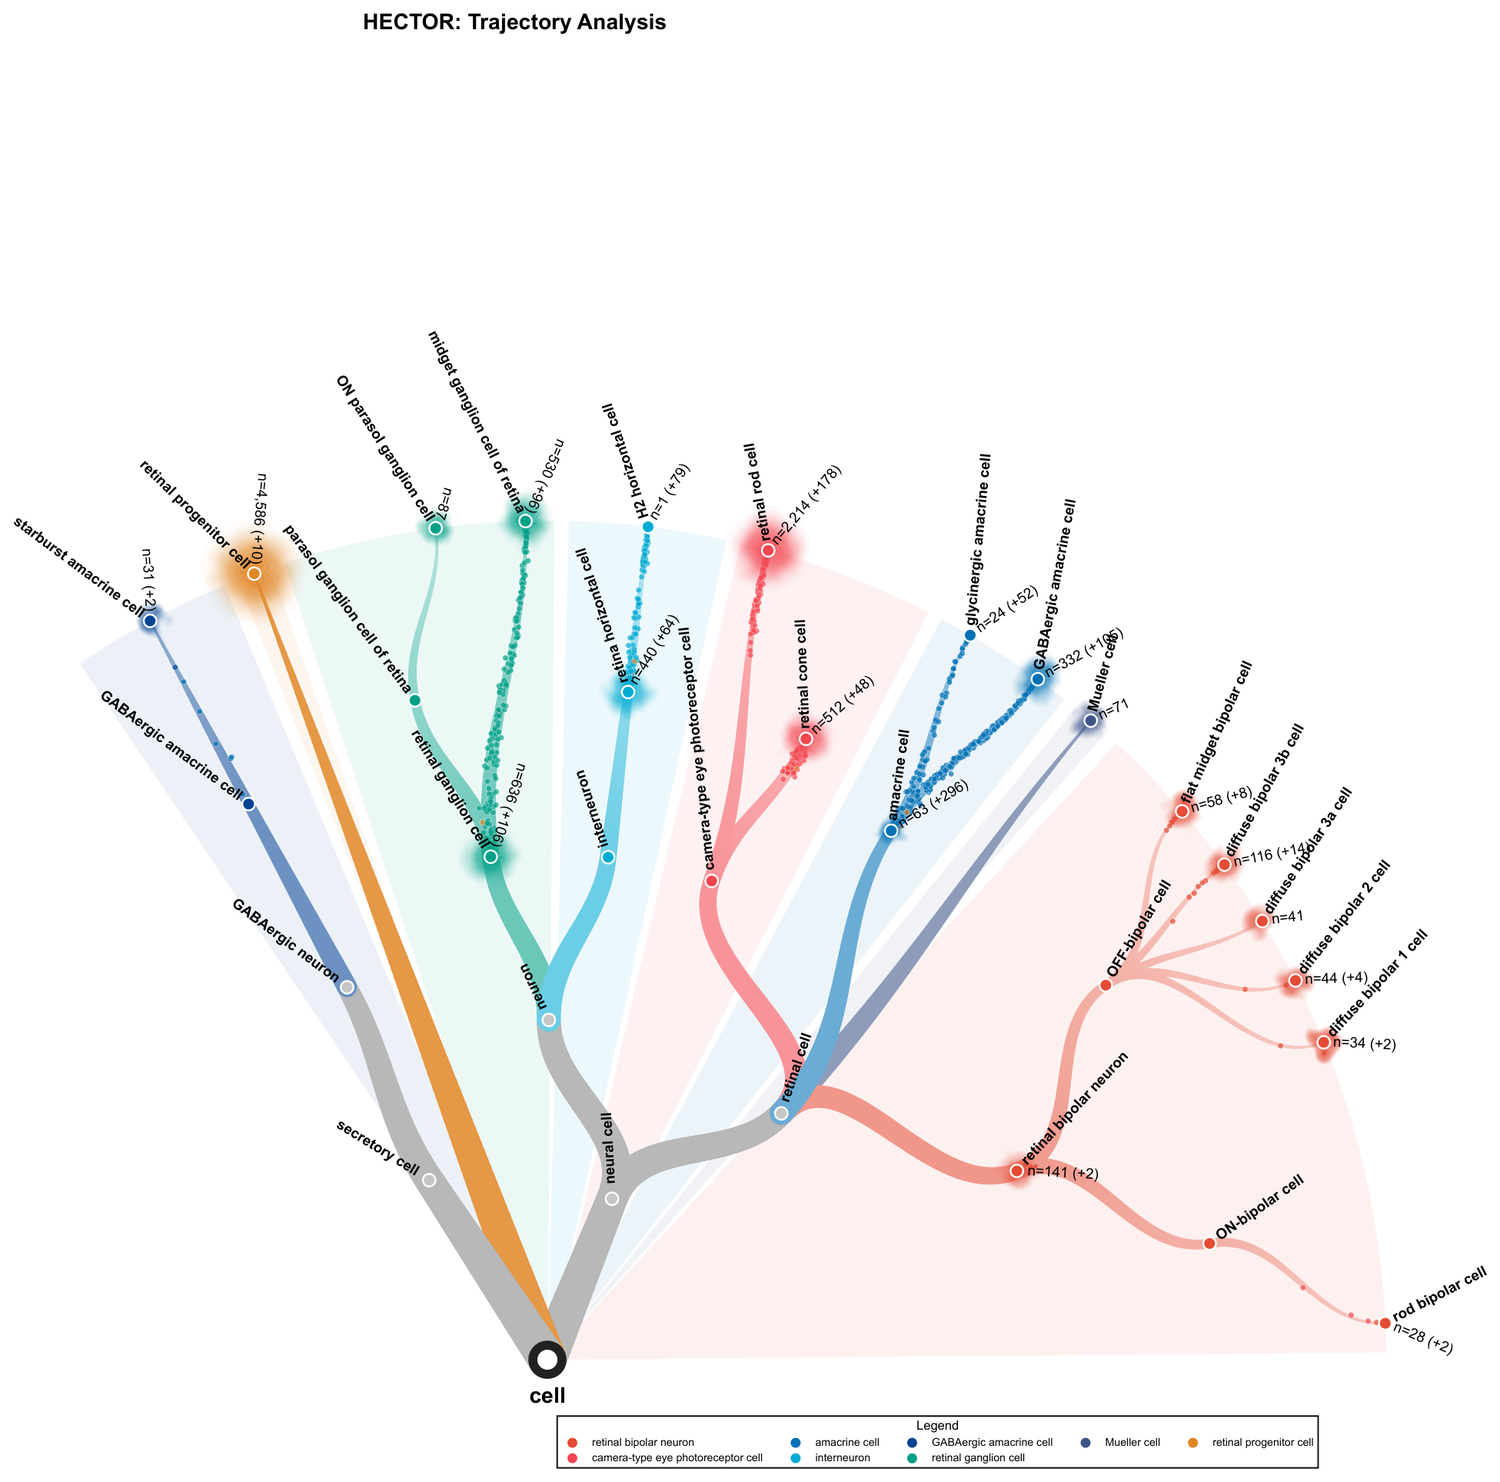

The macula occupies the whole scaffold, 40 nodes of 40; the periphery reaches
only 32. What is missing sits mostly on the bipolar branch, and it is lopsided:

| branch | subtypes drawn in macula | of those, also in periphery |
| --- | --- | --- |
| under `ON-bipolar cell` | 4 | 1 |
| under `OFF-bipolar cell` | 6 | 5 |

So the ON side of the bipolar branch has largely not arrived in the periphery —
invaginating midget (164 cells against 19), diffuse bipolar 6 (42 against 12)
and diffuse bipolar 4 (41 against 3) — while the OFF side is thinner but almost
entirely present. This is not a uniform thinning of that part of the tree.

The reading is that the periphery is running behind. Bipolar cells are the
**last** class a retina builds, and they are the ones missing. The published
analysis of this dataset reports the same thing, and quantifies the lag: for
late-born types such as Müller glia the average timing is week 17 in the macula
against week 22 in the periphery, while for the early-born ganglion cells it is
about week 13 in both.

**One honest caveat about this particular comparison.** The two regions differ
in two ways at once. One is maturity, described above. The other is destiny:
the centre of the eye is built for detail and ends up rich in ganglion and
bipolar cells, while the edge is built for dim light and ends up rich in rods.
The rod count is *higher* in the periphery for that second reason, not the
first. A comparison across time has only one thing in it; this one has two.

## Step 8. What these figures do and do not say

**"Absent" means "below the drawing threshold", not "none".** A type needs 20
cells before it is drawn (`min_cells_number`, tutorial 02 Step 7). The Early
figure appears to have no rods, but there are 12 of them — eight short of being
drawn. In the region comparison, `S cone cell` has 37 cells in the macula and
15 in the periphery, a real but modest difference that the figure turns into a
stark present-or-absent. Check the counts before describing anything as
missing; only the ON-bipolar subtypes differ by enough here that no threshold
choice would change the story.

**The branches are not lineage.** They are the ontology's "is a kind of"
relations, the same as in tutorial 02: a rod *is a kind of* photoreceptor. In
this tree `retinal progenitor cell` sits under `multi fate stem cell` while
`retinal rod cell` sits under `camera-type eye photoreceptor cell` — different
limbs, connected only through the root. A progenitor becoming a rod is a jump
between limbs, and **no line on these figures draws it.** What carries the
developmental story is which nodes are occupied at each stage, not the lines
between them.

**Groups are not required to be the same size.** The scaffold is shared but the
cell counts are each group's own. Comparing counts between figures is only fair
when the groups are of similar size — check with
`adata.obs["stage"].value_counts()` — otherwise compare shares instead.

## Useful settings

Everything `create_trajectory_analysis` accepts also works here and applies to
every figure in the set:

| setting | effect |
| --- | --- |
| `layout_mode` | `"radial"` (default) or `"horizontal"` — tutorial 02 Step 4 |
| `min_cells_number` | cells needed before a type is drawn; default 20 |
| `groups` | which groups to draw, and in what order |
| `label_format` | `"name"` for readable names, `"id"` for ontology identifiers |
| `output_prefix` | filename prefix for the per-group PDF files |

One further option: `create_trajectory_comparison` runs `predict()` once over
all the cells and then splits the results, so every group is annotated in the
same pass. If you have already run `predict()` on the object — as we did in
Step 3 — it reuses that result rather than repeating the work.

## Where next

Tutorial 04 takes the other route through a crowded tree: instead of splitting
the cells into groups, it merges related cell types together, so a figure with
150 labels becomes one with 20.